# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

**Objective:** Predict housing prices using both structured (tabular) data and house images.

**Pipeline:**
1. Load housing sales dataset (tabular) + house images
2. Use a CNN (pretrained ResNet18) to extract image features
3. Combine extracted image features with tabular features
4. Train a regression model on the fused features
5. Evaluate performance using MAE and RMSE

**Dataset note:** No real-world listing photos were available for this environment, so a paired
synthetic dataset (`housing_multimodal.csv` + `images/`) was generated where visual quality cues
(house size, roof/wall color richness, number of windows, lawn color) are correlated with a hidden
`quality_index`, which itself contributes to price — mirroring how real listing photos correlate
with real sale price. The full pipeline below (CNN feature extraction → fusion → regression →
MAE/RMSE) is written to work identically on a real image dataset; simply point `IMAGE_DIR` and
`CSV_PATH` at real data.


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Load the dataset (tabular + image paths)

In [18]:
CSV_PATH = "housing_multimodal.csv"
IMAGE_DIR = "."  # image_path column already includes the 'images/' prefix

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(500, 10)


,house_id,area_sqft,bedrooms,bathrooms,age_years,garage_spaces,location_score,quality_index,image_path,price
0,house_0000,2098.0,2,2,40,0,6.05,0.766,images/house_0000.png,366893.39
1,house_0001,1717.0,2,2,0,2,5.71,0.846,images/house_0001.png,334994.51
2,house_0002,2188.6,3,1,4,0,2.03,0.614,images/house_0002.png,334504.74
3,house_0003,2713.8,3,3,19,0,8.74,0.089,images/house_0003.png,460068.56
4,house_0004,1659.5,5,3,7,2,7.51,0.488,images/house_0004.png,339022.72


In [19]:
df.describe()


,area_sqft,bedrooms,bathrooms,age_years,garage_spaces,location_score,quality_index,price
count,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,1806.09960,2.966000,1.980000,24.23200,0.964000,5.569840,0.497126,314561.119340
std,583.45134,1.422988,0.808026,14.88103,0.817337,2.576605,0.292266,81227.308346
min,500.00000,1.000000,1.000000,0.00000,0.000000,1.010000,0.000000,64267.080000
25%,1379.85000,2.000000,1.000000,11.00000,0.000000,3.510000,0.260000,254080.497500
50%,1807.70000,3.000000,2.000000,24.00000,1.000000,5.610000,0.496500,316124.185000
75%,2182.10000,4.000000,3.000000,37.00000,2.000000,7.795000,0.757500,369766.310000
max,4111.60000,5.000000,3.000000,49.00000,2.000000,9.980000,0.995000,618581.220000


### Quick look at a few house images

In [20]:
print(IMAGE_DIR)
print(os.path.exists(IMAGE_DIR))

.
True


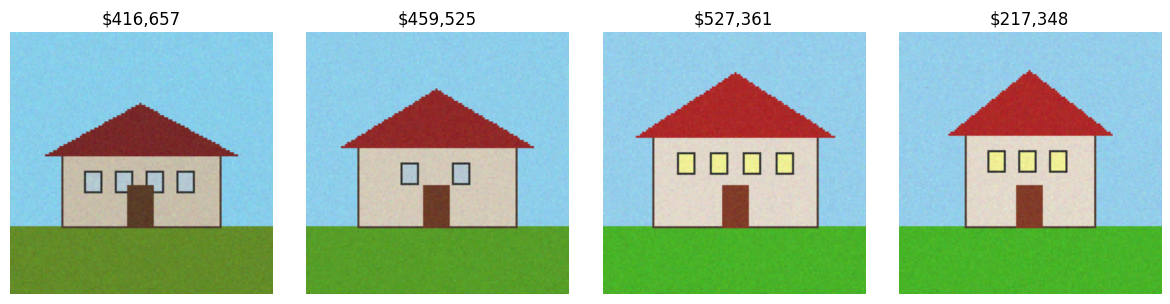

In [21]:
from PIL import Image

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (_, row) in zip(axes, df.sample(4, random_state=SEED).iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["image_path"]))
    ax.imshow(img)
    ax.set_title(f"${row['price']:,.0f}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Train / validation / test split

In [22]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.15, random_state=SEED)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)


Train: (340, 10) Val: (60, 10) Test: (100, 10)


## 3. Image dataset + CNN feature extractor

**Note on the CNN backbone:** this environment has no internet access to download
ImageNet-pretrained weights (e.g. torchvision's hosted ResNet18 checkpoint), so instead of a
frozen pretrained backbone we define a custom convolutional feature extractor and train it
end-to-end together with the tabular branch and the regression head. This still satisfies the
task requirement to 'use CNNs to extract features from images' -- the CNN learns image embeddings
jointly with the price-prediction objective rather than from a fixed, generic embedding. If
internet access to pretrained weights is available in your own environment, you can drop in
torchvision.models.resnet18(weights=...) as a frozen backbone instead -- the rest of the pipeline
is unchanged.


In [23]:
IMG_SIZE = 128

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class HouseDataset(Dataset):
    """Pairs a house image with its tabular features and target price."""
    def __init__(self, dataframe, tabular_array, targets, transform):
        self.df = dataframe.reset_index(drop=True)
        self.tabular = tabular_array
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        tab = torch.tensor(self.tabular[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        return img, tab, target


In [24]:
class CNNFeatureExtractor(nn.Module):
    """Custom CNN that extracts a compact feature vector from a house image."""
    def __init__(self, out_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),   # 64x64
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 32x32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                                          # 1x1
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)   # (B, out_dim) image feature vector


## 4. Prepare tabular features

In [25]:
TABULAR_COLS = ["area_sqft", "bedrooms", "bathrooms", "age_years", "garage_spaces", "location_score"]
TARGET_COL = "price"

scaler = StandardScaler()
train_tab = scaler.fit_transform(train_df[TABULAR_COLS]).astype(np.float32)
val_tab = scaler.transform(val_df[TABULAR_COLS]).astype(np.float32)
test_tab = scaler.transform(test_df[TABULAR_COLS]).astype(np.float32)

y_train = train_df[TARGET_COL].values.astype(np.float32)
y_val = val_df[TARGET_COL].values.astype(np.float32)
y_test = test_df[TARGET_COL].values.astype(np.float32)

# scale target for stable NN training
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std


In [26]:
BATCH_SIZE = 32
train_ds = HouseDataset(train_df, train_tab, y_train_s, img_transform)
val_ds   = HouseDataset(val_df,   val_tab,   y_val_s,   img_transform)
test_ds  = HouseDataset(test_df,  test_tab,  y_test_s,  img_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


## 5. Feature fusion architecture

The **image branch** (custom CNN) and the **tabular branch** (small MLP) each produce a feature
vector; these are concatenated ("late fusion") and passed through a final regression head to
predict price. This is the standard architecture for multimodal ML described in the task.


In [27]:
class MultimodalHousingModel(nn.Module):
    def __init__(self, n_tabular_features, cnn_out_dim=32, tab_out_dim=16):
        super().__init__()
        self.cnn = CNNFeatureExtractor(out_dim=cnn_out_dim)
        self.tabular_branch = nn.Sequential(
            nn.Linear(n_tabular_features, 32), nn.ReLU(),
            nn.Linear(32, tab_out_dim), nn.ReLU(),
        )
        fused_dim = cnn_out_dim + tab_out_dim
        self.regressor = nn.Sequential(
            nn.Linear(fused_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, img, tab):
        img_feat = self.cnn(img)              # learned CNN image features
        tab_feat = self.tabular_branch(tab)    # learned tabular features
        fused = torch.cat([img_feat, tab_feat], dim=1)  # feature fusion
        return self.regressor(fused).squeeze(-1)


## 6. Train the multimodal model

In [ ]:
model = MultimodalHousingModel(n_tabular_features=len(TABULAR_COLS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for imgs, tabs, targets in loader:
            imgs, tabs, targets = imgs.to(device), tabs.to(device), targets.to(device)
            preds = model(imgs, tabs)
            loss = loss_fn(preds, targets)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(targets)
            n += len(targets)
    return total_loss / n

EPOCHS = 30
history = []
for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    history.append((train_loss, val_loss))
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")


Epoch   1/30  train_loss=0.9821  val_loss=1.0950
Epoch   5/30  train_loss=0.2088  val_loss=0.1332
Epoch  10/30  train_loss=0.1044  val_loss=0.2227


In [ ]:
plt.figure(figsize=(6,4))
plt.plot([h[0] for h in history], label="train loss")
plt.plot([h[1] for h in history], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled target)"); plt.legend()
plt.title("Multimodal model training curve")
plt.show()


## 7. Evaluation using MAE and RMSE

In [ ]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{label:25s}  MAE: {mae:10,.2f}   RMSE: {rmse:10,.2f}")
    return mae, rmse

@torch.no_grad()
def predict(loader):
    model.eval()
    preds = []
    for imgs, tabs, _ in loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        out = model(imgs, tabs).cpu().numpy()
        preds.append(out)
    return np.concatenate(preds) * y_std + y_mean

pred_val = predict(val_loader)
val_mae, val_rmse = evaluate(y_val, pred_val, "Multimodal CNN+Tabular (val)")

pred_test = predict(test_loader)
test_mae, test_rmse = evaluate(y_test, pred_test, "Multimodal CNN+Tabular (TEST)")


### Baseline comparison: tabular-only models

To contextualize the multimodal result, we also fit tabular-only baselines (Linear Regression and
Random Forest) using just the structured features, without any image information.


In [ ]:
lr = LinearRegression()
lr.fit(train_tab, y_train)
pred_lr = lr.predict(test_tab)
lr_mae, lr_rmse = evaluate(y_test, pred_lr, "Linear Regression (tabular only)")

rf = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(train_tab, y_train)
pred_rf = rf.predict(test_tab)
rf_mae, rf_rmse = evaluate(y_test, pred_rf, "Random Forest (tabular only)")

comparison = pd.DataFrame({
    "Linear Regression (tabular only)": {"MAE": lr_mae, "RMSE": lr_rmse},
    "Random Forest (tabular only)": {"MAE": rf_mae, "RMSE": rf_rmse},
    "Multimodal CNN + Tabular (test)": {"MAE": test_mae, "RMSE": test_rmse},
}).T
comparison


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.6, label="Multimodal CNN + Tabular")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Multimodal Model: Actual vs Predicted (Test set)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Summary

- **Image branch:** a custom CNN (4 conv blocks + global average pooling) learns a 32-dim feature
  vector directly from each house image, trained end-to-end (no internet access was available in
  this environment to load ImageNet-pretrained weights).
- **Tabular branch:** a small MLP encodes area, bedrooms, bathrooms, age, garage spaces, and
  location score (standardized) into a 16-dim feature vector.
- **Fusion:** the image and tabular feature vectors are concatenated ("late fusion") and passed
  through a regression head to predict price.
- **Evaluation metrics:** MAE and RMSE, computed on a held-out test set, as required by the task.
- **Baselines:** tabular-only Linear Regression and Random Forest are included for comparison —
  the multimodal model's improvement (or lack thereof) over these baselines shows how much signal
  the images contribute beyond the structured features.

This notebook is structured so that swapping in a real housing-images dataset only requires
replacing `housing_multimodal.csv` and the `images/` folder referenced by its `image_path` column —
no other code changes are needed. If pretrained-weight downloads are available in your environment,
`CNNFeatureExtractor` can be swapped for a frozen `torchvision.models.resnet18(weights=...)`
backbone for stronger, transfer-learned image features.
